# IronHorse Leave-One-Out YOLO Evaluation

## Purpose

This notebook is to test YOLO model performance using a leave-one-out/ k-fold style workflow on the Iron Horse data set

The first part of the notebook creates folds based on video folders. For each fold, one video is held out as the validation set, while the remaining videos are used for training. This helps test whether the model can generalize to a video it has not seen during training

Later sections of the notebook are used to manually adjust YOLO prediction settings, especially the confidence threshold and IoU threshold, with the goal of finding more bounding boxes during prediction review

## What this notebook does

This notebook performs the following steps:

1. **Mounts Google Drive**  
   Connects Colab to Google Drive so the dataset ZIP file can be accessed

2. **Extracts the separated dataset ZIP file**  
   Unzips the dataset into the Colab runtime

3. **Creates leave-one-video-out folds**  
   Each video folder becomes its own validation fold. For example, if `Video 011` is the validation video, all other videos are used for training

4. **Writes a YOLO `data.yaml` file for each fold**  
   Each fold receives its own dataset configuration file so YOLO knows where the training and validation images are located

5. **Trains YOLO on each fold**  
   A fresh YOLOv8 model is trained separately for every fold

6. **Validates selected fold models**  
   The notebook loads trained model weights for specific folds and prints metrics such as precision, recall, mAP50, and mAP50-95

7. **Plots training metrics**  
   Reads each fold’s `results.csv` file and plots validation metrics over training epochs

8. **Displays confusion matrices**  
   Opens the confusion matrix image produced during training for each reviewed fold

9. **Compares ground-truth boxes with model predictions**  
   Creates review images showing both the original labels and the model’s predicted boxes

10. **Experiments with confidence and IoU thresholds**  
   Several sections manually change `CONF_THRES` and `IOU_THRES` to see whether lower or higher thresholds help reveal more bounding boxes

11. **Zips visual review images**  
   Saves the generated ground-truth-versus-prediction images into ZIP files for downloading from Colab

## How to use this notebook

1. Ensure the dataset zip file is stored in Google Drive
2. Check and update the dataset ZIP path if needed:

   ```python
   zip_path = "/content/drive/MyDrive/SeparatedDataSet.zip"
   ```
3. Run the setup cells
4. Run the YOLO training cell to train every fold
5. After training, review each fold by loading the correct model path and fold YAML file
6. For each fold, check or update these paths before running validation
```python
model = YOLO("/content/yolo_folds/fold_Video 012/weights/best.pt")
metrics = model.val(data="/content/folds/fold_Video 012/data.yaml")
```
7. Adjust the confidence and IoU thresholds when reviewing predictions
```python
CONF_THRES = 0.20
IOU_THRES = 0.50
```
8. Review the ground-truth-versus-prediction images
9. Download the zip files created to inspect later


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/SeparatedDataSet.zip"

extract_dir = "/content/dataset_raw"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Top-level contents:", os.listdir(extract_dir)[:10])

Extracted to: /content/dataset_raw
Top-level contents: ['Video 012', 'Video 011', 'Video 014', 'video 0']


In [ ]:
from pathlib import Path
import shutil
import yaml

SOURCE_ROOT = Path("/content/dataset_raw")
OUTPUT_ROOT = Path("/content//folds")

CLASS_NAMES = ["unhealthly_leaf"]
COPY_FILES = True  # True = copy files, False = symlink files

# =========================
# Helper functions
# =========================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_video_folders(source_root):
    """Return subfolders that contain train/images and train/labels."""
    video_folders = []

    for folder in sorted(source_root.iterdir()):
        if not folder.is_dir():
            continue

        img_dir = folder / "train" / "images"
        lbl_dir = folder / "train" / "labels"

        if img_dir.exists() and lbl_dir.exists():
            video_folders.append(folder)

    return video_folders


def link_or_copy(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists():
        return

    if COPY_FILES:
        shutil.copy2(src, dst)
    else:
        dst.symlink_to(src)


def add_video_to_split(video_folder, fold_root, split):
    """
    Adds one video's images and labels to a YOLO split.
    split should be 'train' or 'val'.
    """
    src_img_dir = video_folder / "train" / "images"
    src_lbl_dir = video_folder / "train" / "labels"

    dst_img_dir = fold_root / "images" / split
    dst_lbl_dir = fold_root / "labels" / split

    for img_path in sorted(src_img_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        # Prefix filenames with video folder name to avoid duplicate names across videos
        new_img_name = f"{video_folder.name}_{img_path.name}"
        dst_img_path = dst_img_dir / new_img_name

        link_or_copy(img_path, dst_img_path)

        # YOLO label should have same stem as image, with .txt extension
        src_label_path = src_lbl_dir / f"{img_path.stem}.txt"
        new_label_name = f"{video_folder.name}_{img_path.stem}.txt"
        dst_label_path = dst_lbl_dir / new_label_name

        if src_label_path.exists():
            link_or_copy(src_label_path, dst_label_path)
        else:
            # Optional: create empty label file for images with no objects
            dst_label_path.parent.mkdir(parents=True, exist_ok=True)
            dst_label_path.touch()


def write_data_yaml(fold_root, class_names):
    data = {
        "path": str(fold_root),
        "train": "images/train",
        "val": "images/val",
        "names": {i: name for i, name in enumerate(class_names)}
    }

    with open(fold_root / "data.yaml", "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)


# =========================
# Main leave-one-out split
# =========================
video_folders = get_video_folders(SOURCE_ROOT)

print(f"Found {len(video_folders)} video folders:")
for v in video_folders:
    print(" -", v.name)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

for val_video in video_folders:
    fold_root = OUTPUT_ROOT / f"fold_{val_video.name}"

    print(f"\nCreating fold: {fold_root.name}")
    print(f"Validation video: {val_video.name}")

    # Optional: remove old fold before recreating
    if fold_root.exists():
        shutil.rmtree(fold_root)

    # Create train/val folders
    for split in ["train", "val"]:
        (fold_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (fold_root / "labels" / split).mkdir(parents=True, exist_ok=True)

    # Add videos
    for video in video_folders:
        if video == val_video:
            add_video_to_split(video, fold_root, "val")
        else:
            add_video_to_split(video, fold_root, "train")

    write_data_yaml(fold_root, CLASS_NAMES)


Found 4 video folders:
 - Video 011
 - Video 012
 - Video 014
 - video 0

Creating fold: fold_Video 011
Validation video: Video 011

Creating fold: fold_Video 012
Validation video: Video 012

Creating fold: fold_Video 014
Validation video: Video 014

Creating fold: fold_video 0
Validation video: video 0


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.0 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
from pathlib import Path

folds_root = Path("/content/folds")
results_root = "/content/yolo_folds/"

for fold_root in sorted(folds_root.iterdir()):
    if not fold_root.is_dir():
        continue

    data_yaml = fold_root / "data.yaml"

    if not data_yaml.exists():
        print(f"Skipping {fold_root.name}: no data.yaml found")
        continue

    print(f"\nTraining fold: {fold_root.name}")

    # Fresh model for each fold
    model = YOLO("yolov8s.pt")

    model.train(
        data=str(data_yaml),
        epochs=100,
        patience=15,
        imgsz=1280,
        batch=16,
        project=results_root,
        name=fold_root.name,
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Training fold: fold_Video 011
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/folds/fold_Video 011/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exi

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
from pathlib import Path

model = YOLO("/content/drive/MyDrive/454/v011/best.pt")
metrics = model.val(
    data="/content/folds/fold_Video 011/data.yaml",
    conf = .20,
    iou = .50)

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3451.4±921.9 MB/s, size: 573.5 KB)
val: Scanning /content/folds/fold_Video 011/labels/val... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 295.7it/s 0.0s
val: New cache created: /content/folds/fold_Video 011/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4s/it 1.4s
                   all         14         40      0.632      0.275      0.228      0.122
Speed: 2.6ms preprocess, 6.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val-3
Fold_2metrics
Precision: 0.6321761796269546
Recall: 0.275
mAP50: 0.22773156990068757
mAP50-95: 0.12230207537560481


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/yolo_folds/fold_Video 011/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/yolo_folds/fold_Video 011/results.csv'

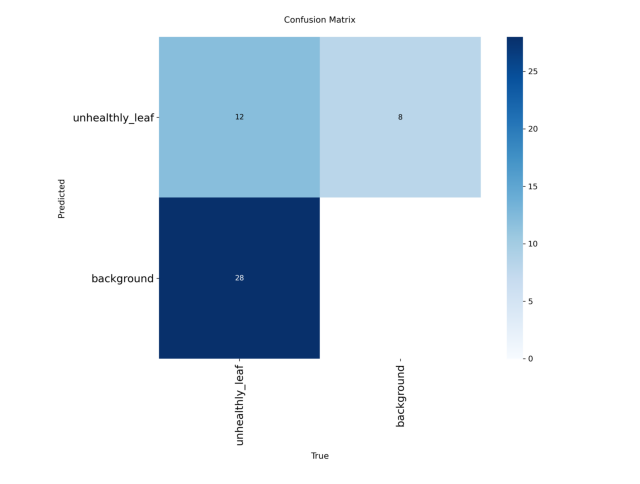

In [ ]:
from PIL import Image

img = Image.open("/content/yolo_folds/fold_Video 011/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
from pathlib import Path
import os

model_path = "/content/drive/MyDrive/454/v011/best.pt"   # change if needed
dataset_root = Path("/content/folds/fold_Video 011")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video011")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (255, 0, 0)    # blue

# prediction settings
CONF_THRES = 0.20
IOU_THRES = 0.50

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 227 images from /content/folds/fold_Video 011/images/train
Saved outputs to /content/gt_vs_pred_fold_Video011/train
Processing 14 images from /content/folds/fold_Video 011/images/val
Saved outputs to /content/gt_vs_pred_fold_Video011/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video011


In [ ]:
import shutil

review_dir = "/content/gt_vs_pred_fold_Video011"
zip_base = "/content/gt_vs_pred_fold_Video011"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video011.zip


In [ ]:
model = YOLO("/content/yolo_folds/fold_Video 012/weights/best.pt")
metrics = model.val(data="/content/folds/fold_Video 012/data.yaml",conf = .15,
    iou = .60)

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3078.8±1319.0 MB/s, size: 556.0 KB)
val: Scanning /content/folds/fold_Video 012/labels/val.cache... 53 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53 17.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.2s
                   all         53        130      0.421      0.554      0.386      0.134
Speed: 15.8ms preprocess, 3.7ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /content/runs/detect/val-30
Fold_2metrics
Precision: 0.42120735214538824
Recall: 0.5538461538461539
mAP50: 0.38644925556115206
mAP50-95: 0.13446542998387062


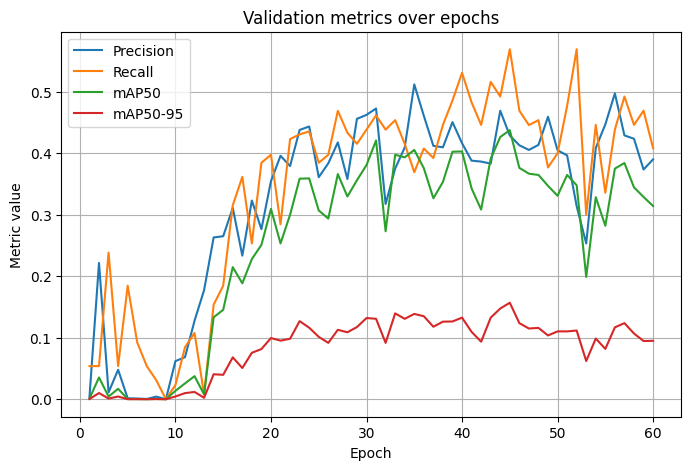

In [ ]:
df = pd.read_csv("/content/yolo_folds/fold_Video 012/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

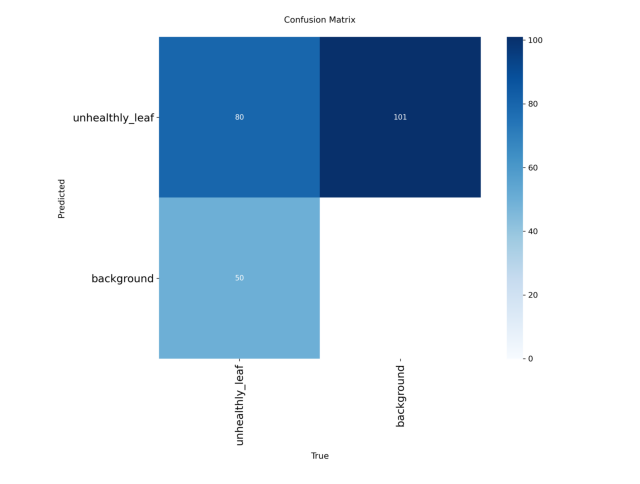

In [ ]:
img = Image.open("/content/yolo_folds/fold_Video 012/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

model_path = "/content/yolo_folds/fold_Video 012/weights/best.pt"   # change if needed
dataset_root = Path("/content/folds/fold_Video 012")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video012")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (255, 0, 0)    # blue

# prediction settings
CONF_THRES = 0.50
IOU_THRES = 0.50

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 188 images from /content/folds/fold_Video 012/images/train
Saved outputs to /content/gt_vs_pred_fold_Video012/train
Processing 53 images from /content/folds/fold_Video 012/images/val
Saved outputs to /content/gt_vs_pred_fold_Video012/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video012


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video012"
zip_base = "/content/gt_vs_pred_fold_Video012"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video012.zip


In [ ]:


model = YOLO("/content/yolo_folds/fold_Video 014/weights/best.pt")
metrics = model.val(data="/content/folds/fold_Video 014/data.yaml",conf = .15,
    iou = .50)

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3186.2±571.2 MB/s, size: 679.0 KB)
val: Scanning /content/folds/fold_Video 014/labels/val... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 629.1it/s 0.1s
val: New cache created: /content/folds/fold_Video 014/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.8s
                   all         45         96        0.8      0.167      0.149     0.0584
Speed: 9.8ms preprocess, 11.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val
Fold_2metrics
Precision: 0.8
Recall: 0.16666666666666666
mAP50: 0.14941295546558703
mAP50-95: 0.05840635865682305


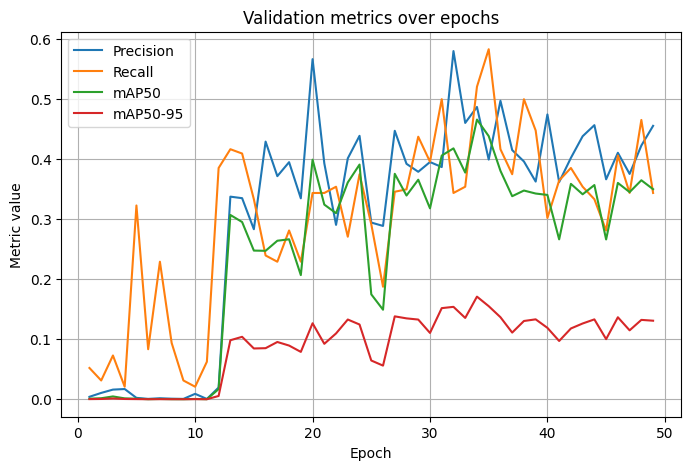

In [ ]:
df = pd.read_csv("/content/yolo_folds/fold_Video 014/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

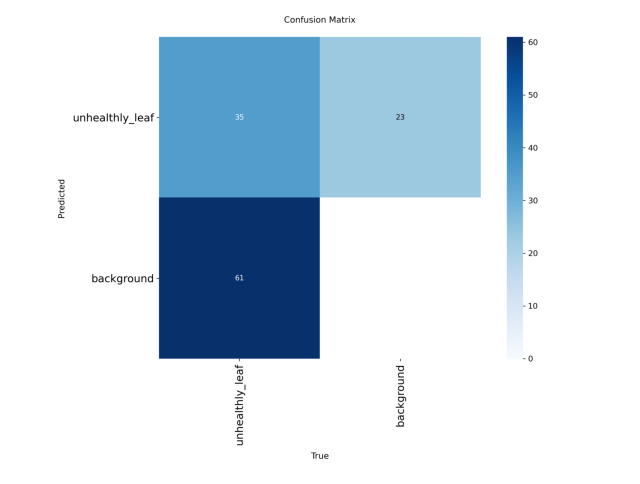

In [ ]:
img = Image.open("/content/yolo_folds/fold_Video 014/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

model_path = "/content/yolo_folds/fold_Video 014/weights/best.pt"   # change if needed
dataset_root = Path("/content/folds/fold_Video 014")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video014")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (255, 0, 0)    # blue

# prediction settings
CONF_THRES = 0.10
IOU_THRES = 0.10

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 196 images from /content/folds/fold_Video 014/images/train
Saved outputs to /content/gt_vs_pred_fold_Video014/train
Processing 45 images from /content/folds/fold_Video 014/images/val
Saved outputs to /content/gt_vs_pred_fold_Video014/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video014


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video014"
zip_base = "/content/gt_vs_pred_fold_Video014"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video014.zip


In [ ]:
model = YOLO("/content/yolo_folds/fold_video 0/weights/best.pt")
metrics = model.val(
    data="/content/folds/fold_video 0/data.yaml",
    conf = .60,
    iou = .60
)

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4160.0±639.1 MB/s, size: 1742.3 KB)
val: Scanning /content/folds/fold_video 0/labels/val.cache... 129 images, 29 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 41.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.9it/s 3.1s
                   all        129        288      0.358      0.184     0.0784     0.0229
Speed: 4.7ms preprocess, 4.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-11
Fold_2metrics
Precision: 0.3581081081081081
Recall: 0.1840277777777778
mAP50: 0.07839780218454545
mAP50-95: 0.022893946465219916


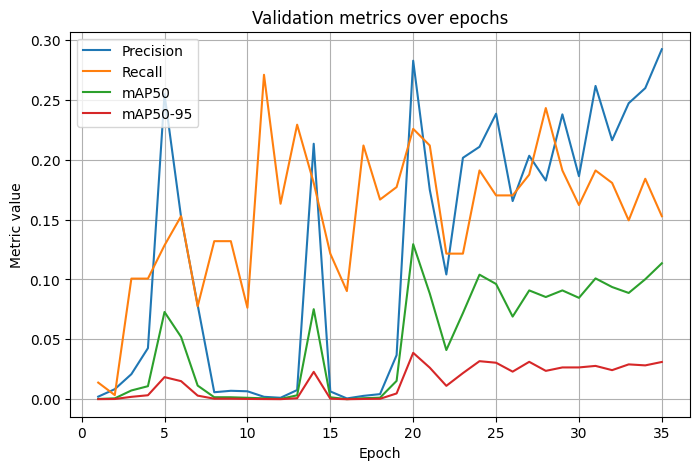

In [ ]:
df = pd.read_csv("/content/yolo_folds/fold_video 0/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

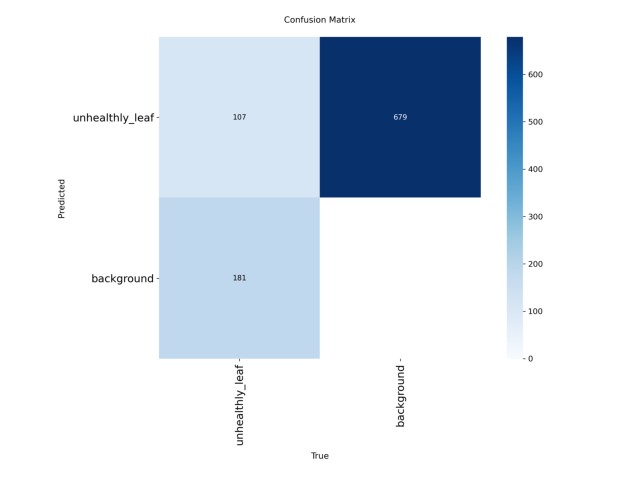

In [ ]:
img = Image.open("/content/yolo_folds/fold_video 0/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

model_path = "/content/yolo_folds/fold_video 0/weights/best.pt"   # change if needed
dataset_root = Path("/content/folds/fold_video 0")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video0")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (255, 0, 0)    # blue

# prediction settings
CONF_THRES = 0.50
IOU_THRES = 0.50

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 112 images from /content/folds/fold_video 0/images/train
Saved outputs to /content/gt_vs_pred_fold_Video0/train
Processing 129 images from /content/folds/fold_video 0/images/val
Saved outputs to /content/gt_vs_pred_fold_Video0/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video0


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video0"
zip_base = "/content/gt_vs_pred_fold_Video0"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video0.zip
